<a href="https://colab.research.google.com/github/BrenooOliveira/AulasFatec/blob/main/tcc/benchmark_rag_vectordbs.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Benchmark Comparativo: FAISS × Milvus × Chroma em Pipelines RAG
**Versão 2 — Otimizada para Google Colab Gratuito**

**Trabalho de Conclusão de Curso — Análise e Desenvolvimento de Sistemas**
**Autor:** Breno Alves
**Título:** Comparação de Bancos de Vetores Aplicados a Soluções de Geração Aumentada de Recuperação (RAG)

---

## Como executar

1. Abra este notebook no Google Colab
2. Conecte ao ambiente de execução padrão (CPU, ~12 GB RAM)
3. Execute as células em ordem sequencial — **não pule nenhuma**
4. Os resultados são salvos automaticamente no Google Drive (pasta `TCC_BenchmarkRAG`)
5. Se o Colab desconectar, os CSVs parciais no Drive preservam o progresso

## Cenários experimentais

| Cenário | Volume | Embeddings |
|---------|--------|------------|
| **S1** | 10.000 vetores | Reais — corpus ag_news + all-MiniLM-L6-v2 |
| **S2** | 100.000 vetores | Sintéticos normalizados (384 dims) |
| **S3** | 500.000 vetores | Sintéticos normalizados (384 dims) |

## Métricas coletadas
- Tempo de indexação (s)
- Latência p50, p90, p99 (ms/query) com IC 95%
- Throughput — Queries por Segundo (QPS)
- Recall@k (k = 1, 5, 10)
- Consumo de RAM — delta em MB
- Tamanho do índice em disco (MB)

## Análise estatística
- N = 10 repetições por banco/cenário (1 warm-up descartado)
- Intervalo de confiança 95% via t-distribution (scipy)
- Teste Wilcoxon signed-rank entre pares de bancos por cenário

> **Nota:** O experimento não inclui LLM. Recall@k é a métrica de qualidade semântica (padrão ANN-Benchmarks).


## Célula 1 — Google Drive

Monta o Drive para persistência de resultados. Execute mesmo que já esteja montado.

In [1]:
try:
    from google.colab import drive
    drive.mount('/content/drive', force_remount=False)
    DRIVE_OUTPUT = '/content/drive/MyDrive/TCC_BenchmarkRAG'
    IN_COLAB = True
    print("✅ Google Drive montado.")
except ModuleNotFoundError:
    # Execução local (fora do Colab)
    DRIVE_OUTPUT = './benchmark_output_drive'
    IN_COLAB = False
    print("ℹ️  Executando fora do Colab — Drive desabilitado. Resultados apenas em WORK_DIR.")

import os
os.makedirs(DRIVE_OUTPUT, exist_ok=True)
print(f"   Saída no Drive: {DRIVE_OUTPUT}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Google Drive montado.
   Saída no Drive: /content/drive/MyDrive/TCC_BenchmarkRAG


## Célula 2 — Instalação de Dependências

> Versões fixadas para garantir reprodutibilidade. Tempo estimado: 3–5 min.

In [2]:
%pip install -q \
    "faiss-cpu==1.9.0" \
    "pymilvus==2.5.8" \
    "chromadb==0.6.3" \
    "sentence-transformers==3.4.1" \
    "datasets==3.2.0" \
    "psutil==6.1.1" \
    "scipy==1.15.2" \
    "matplotlib>=3.10.0" \
    "seaborn>=0.13.2" \
    "tqdm==4.67.1"

print("\n✅ Dependências instaladas com sucesso.")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 1.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 57.7/57.7 kB 2.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.0/52.0 kB 1.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 1.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 27.5/27.5 MB 44.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 227.6/227.6 kB 10.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 611.1/611.1 kB 24.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 275.9/275.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 480.6/480.6 kB 16.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 287.5/287.5 kB 16.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 25.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.5/78.5 kB 5.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

## Célula 3 — Imports e Configuração Global

In [3]:
import os, gc, time, shutil, warnings, json, datetime
import numpy as np
import pandas as pd
import psutil
import faiss
import chromadb
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
from scipy import stats
from tqdm.notebook import tqdm
from sentence_transformers import SentenceTransformer
from pymilvus import MilvusClient
from typing import List, Dict, Tuple, Optional
from contextlib import contextmanager

warnings.filterwarnings("ignore")

# ─── Modo Colab ────────────────────────────────────────────────────────────────
COLAB_MODE = True   # Fixo: S3 = 500k, ajustado para ~12 GB RAM

# ─── Configuração reprodutível ─────────────────────────────────────────────────
SEED          = 42
np.random.seed(SEED)

# ─── Parâmetros dos cenários ───────────────────────────────────────────────────
EMBEDDING_DIM = 384
SCENARIO_SIZES = {
    "S1_10k":   10_000,
    "S2_100k":  100_000,
    "S3_500k":  500_000,   # D1: 500k no Colab (era 1M no projeto original)
}
TOP_K_VALUES  = [1, 5, 10]
N_QUERIES     = 200
N_RUNS        = 10         # D4: 10 repetições para IC 95% e Wilcoxon

# ─── Timeout para operações lentas (Chroma no S3) ─────────────────────────────
CHROMA_S3_TIMEOUT_MIN = 30   # se inserção > 30 min, registrar como achado (D6)

# ─── Diretórios de trabalho ────────────────────────────────────────────────────
WORK_DIR   = Path("./benchmark_output")
FAISS_DIR  = WORK_DIR / "faiss_indices"
WORK_DIR.mkdir(exist_ok=True)
FAISS_DIR.mkdir(exist_ok=True)

# ─── Paleta de cores ───────────────────────────────────────────────────────────
COLORS = {
    "FAISS":  "#3B82F6",   # azul
    "Milvus": "#10B981",   # verde
    "Chroma": "#F59E0B",   # âmbar
}

plt.rcParams.update({
    "figure.dpi":        150,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "DejaVu Sans",
})

print(f"✅ Configuração carregada")
print(f"   COLAB_MODE = {COLAB_MODE}")
print(f"   Cenários:   {list(SCENARIO_SIZES.keys())}")
print(f"   dim={EMBEDDING_DIM} | seed={SEED} | N_RUNS={N_RUNS} | N_QUERIES={N_QUERIES}")
print(f"   WORK_DIR:   {WORK_DIR.resolve()}")


✅ Configuração carregada
   COLAB_MODE = True
   Cenários:   ['S1_10k', 'S2_100k', 'S3_500k']
   dim=384 | seed=42 | N_RUNS=10 | N_QUERIES=200
   WORK_DIR:   /content/benchmark_output


## Célula 4 — Utilitários de Medição

In [4]:
def get_memory_mb() -> float:
    """RAM do processo atual em MB."""
    return psutil.Process(os.getpid()).memory_info().rss / (1024 ** 2)


@contextmanager
def measure_memory():
    """Captura delta de RAM (MB) durante o bloco."""
    gc.collect()
    mem_before = get_memory_mb()
    stats_dict = {"peak_delta_mb": 0.0, "baseline_mb": mem_before}
    try:
        yield stats_dict
    finally:
        gc.collect()
        mem_after = get_memory_mb()
        stats_dict["peak_delta_mb"] = max(0.0, mem_after - mem_before)


def measure_latency_percentiles(query_fn, queries: np.ndarray, n_runs: int = N_RUNS) -> Dict:
    """
    Executa query_fn(queries) n_runs vezes (+ 1 warm-up descartado).
    Retorna estatísticas de latência por query (ms), IC 95% e runs brutas.
    """
    latencies_ms = []
    for i in range(n_runs + 1):          # +1 = warm-up
        t0 = time.perf_counter()
        query_fn(queries)
        elapsed_ms = (time.perf_counter() - t0) * 1000 / len(queries)
        if i > 0:
            latencies_ms.append(elapsed_ms)

    arr = np.array(latencies_ms)
    n   = len(arr)
    se  = arr.std(ddof=1) / np.sqrt(n)
    ci  = stats.t.interval(0.95, df=n-1, loc=arr.mean(), scale=se)

    return {
        "p50_ms":          float(np.percentile(arr, 50)),
        "p90_ms":          float(np.percentile(arr, 90)),
        "p99_ms":          float(np.percentile(arr, 99)),
        "mean_ms":         float(arr.mean()),
        "std_ms":          float(arr.std(ddof=1)),
        "ci95_lower_ms":   float(ci[0]),
        "ci95_upper_ms":   float(ci[1]),
        "qps":             float(1000 / arr.mean()),
        "runs_ms":         latencies_ms,    # necessário para Wilcoxon
    }


def compute_recall_at_k(retrieved: np.ndarray, ground_truth: np.ndarray, k: int) -> float:
    """
    Recall@k = fração de queries onde ao menos 1 resultado verdadeiro
    está entre os k recuperados. Métrica padrão ANN-Benchmarks.
    """
    hits = sum(
        bool(set(ground_truth[i, :k]) & set(retrieved[i, :k]))
        for i in range(len(retrieved))
    )
    return hits / len(retrieved)


def get_dir_size_mb(path: Path) -> float:
    """Tamanho em MB de diretório ou arquivo."""
    if path.is_file():
        return path.stat().st_size / (1024 ** 2)
    if path.is_dir():
        return sum(f.stat().st_size for f in path.rglob("*") if f.is_file()) / (1024 ** 2)
    return 0.0


def save_checkpoint(df_rows: list, filename: str) -> None:
    """Salva CSV incremental em WORK_DIR e no Drive."""
    if not df_rows:
        return
    path_local = WORK_DIR / filename
    pd.DataFrame(df_rows).to_csv(path_local, index=False)
    path_drive = Path(DRIVE_OUTPUT) / filename
    try:
        shutil.copy(path_local, path_drive)
    except Exception:
        pass   # Drive pode não estar disponível localmente


print("✅ Utilitários de medição definidos.")
print("   Novidades v2: IC 95%, runs_ms para Wilcoxon, save_checkpoint()")


✅ Utilitários de medição definidos.
   Novidades v2: IC 95%, runs_ms para Wilcoxon, save_checkpoint()


## Seção 3 — Geração de Dados

### 3.1 Cenário S1 — Embeddings Reais (10k)

Corpus **ag_news** (notícias em inglês) codificado com `all-MiniLM-L6-v2`.  
Permite avaliar qualidade de recuperação em condições próximas a um pipeline RAG real.


In [5]:
from datasets import load_dataset

N_REAL = SCENARIO_SIZES["S1_10k"]
print(f"⏳ Carregando ag_news — {N_REAL:,} amostras para corpus + {N_QUERIES} para queries...")
ds          = load_dataset("ag_news", split="train", trust_remote_code=True)
texts_10k   = [row["text"] for row in ds.select(range(N_REAL))]

print("⏳ Carregando modelo all-MiniLM-L6-v2...")
embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2")

print(f"⏳ Gerando {N_REAL:,} embeddings reais (2–3 min)...")
with measure_memory() as mem_embed:
    embeddings_10k = embedder.encode(
        texts_10k,
        batch_size=256,
        show_progress_bar=True,
        normalize_embeddings=True,
    ).astype(np.float32)

query_texts_10k = [row["text"] for row in ds.select(range(N_REAL, N_REAL + N_QUERIES))]
query_vecs_10k  = embedder.encode(
    query_texts_10k, batch_size=256, normalize_embeddings=True
).astype(np.float32)

ram_s1 = get_memory_mb()
print(f"\n✅ S1 | corpus={embeddings_10k.shape} | queries={query_vecs_10k.shape}")
print(f"   RAM consumida na geração: {mem_embed['peak_delta_mb']:.1f} MB")
print(f"   RAM total do processo:    {ram_s1:.1f} MB")


⏳ Carregando ag_news — 10,000 amostras para corpus + 200 para queries...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

⏳ Gerando 10,000 embeddings reais (2–3 min)...


Batches:   0%|          | 0/40 [00:00<?, ?it/s]


✅ S1 | corpus=(10000, 384) | queries=(200, 384)
   RAM consumida na geração: 450.3 MB
   RAM total do processo:    1743.7 MB


### 3.2 Cenários S2 e S3 — Vetores Sintéticos Normalizados

In [6]:
def generate_synthetic_vectors(n: int, dim: int, seed: int = SEED) -> np.ndarray:
    """
    Vetores gaussianos normalizados em R^dim.
    Normalização garante equivalência entre produto interno e cosine similarity,
    replicando o comportamento de embeddings reais normalizados.
    """
    rng   = np.random.default_rng(seed)
    vecs  = rng.standard_normal((n, dim)).astype(np.float32)
    norms = np.linalg.norm(vecs, axis=1, keepdims=True)
    return vecs / norms


print("⏳ Gerando vetores sintéticos para S2 (100k)...")
embeddings_100k = generate_synthetic_vectors(SCENARIO_SIZES["S2_100k"], EMBEDDING_DIM)
query_vecs_100k = generate_synthetic_vectors(N_QUERIES, EMBEDDING_DIM, seed=SEED + 1)

print("⏳ Gerando vetores sintéticos para S3 (500k — D1: viabilidade Colab)...")
embeddings_500k = generate_synthetic_vectors(SCENARIO_SIZES["S3_500k"], EMBEDDING_DIM)
query_vecs_500k = generate_synthetic_vectors(N_QUERIES, EMBEDDING_DIM, seed=SEED + 2)

ram_after_gen = get_memory_mb()
print(f"\n✅ S2 | corpus={embeddings_100k.shape} | {embeddings_100k.nbytes / 1e6:.1f} MB")
print(f"✅ S3 | corpus={embeddings_500k.shape} | {embeddings_500k.nbytes / 1e6:.0f} MB")
print(f"   RAM total do processo: {ram_after_gen:.1f} MB")


⏳ Gerando vetores sintéticos para S2 (100k)...
⏳ Gerando vetores sintéticos para S3 (500k — D1: viabilidade Colab)...

✅ S2 | corpus=(100000, 384) | 153.6 MB
✅ S3 | corpus=(500000, 384) | 768 MB
   RAM total do processo: 2622.6 MB


### 3.3 Ground Truth — Oráculo de Busca Exata

Recall@k é calculado contra o resultado de `IndexFlatIP` (produto interno exato) do FAISS — prática padrão do ANN-Benchmarks. O oráculo não usa aproximação, portanto seu Recall@k = 1.0 por definição.


In [7]:
def compute_ground_truth(corpus: np.ndarray, queries: np.ndarray, k: int = max(TOP_K_VALUES)) -> np.ndarray:
    """Busca exata via FAISS IndexFlatIP. Retorna (n_queries, k) com índices verdadeiros."""
    index = faiss.IndexFlatIP(corpus.shape[1])
    index.add(corpus)
    _, I = index.search(queries, k)
    del index
    gc.collect()
    return I


print("⏳ Computando ground truth — S1 (10k)...")
gt_10k  = compute_ground_truth(embeddings_10k, query_vecs_10k)

print("⏳ Computando ground truth — S2 (100k)...")
gt_100k = compute_ground_truth(embeddings_100k, query_vecs_100k)

print("⏳ Computando ground truth — S3 (500k, ~20 s)...")
gt_500k = compute_ground_truth(embeddings_500k, query_vecs_500k)

print("\n✅ Ground truth computado para todos os cenários.")
print(f"   gt_10k={gt_10k.shape} | gt_100k={gt_100k.shape} | gt_500k={gt_500k.shape}")


⏳ Computando ground truth — S1 (10k)...
⏳ Computando ground truth — S2 (100k)...
⏳ Computando ground truth — S3 (500k, ~20 s)...

✅ Ground truth computado para todos os cenários.
   gt_10k=(200, 10) | gt_100k=(200, 10) | gt_500k=(200, 10)


## Seção 4 — Benchmark FAISS

Configurações avaliadas:
- `IndexFlatIP` — busca exata (baseline; Recall@k = 1.0 por definição)
- `IndexHNSWFlat(M=32)` — grafo hierárquico, configuração ANN padrão de produção
- `IndexIVFFlat` — Inverted File Index; adicionado **apenas no S3** (D3)

A célula salva um CSV incremental após cada cenário para preservar progresso em caso de desconexão.


In [8]:
FAISS_ROWS = []   # acumula todas as linhas para o CSV detalhado

def benchmark_faiss(corpus, queries, ground_truth, scenario_name, k=10):
    n, dim = corpus.shape
    results = {}

    index_configs = {
        "Flat_exato":  lambda: faiss.IndexFlatIP(dim),
        "HNSW-32":     lambda: faiss.IndexHNSWFlat(dim, 32),
    }
    if n >= 500_000:   # IVF apenas no S3 (D3)
        nlist = int(np.sqrt(n))
        def _build_ivf():
            q = faiss.IndexFlatIP(dim)
            return faiss.IndexIVFFlat(q, dim, nlist, faiss.METRIC_INNER_PRODUCT)
        index_configs[f"IVF{nlist}"] = _build_ivf

    for idx_name, buld_fn in index_configs.items():
        print(f"    ├─ FAISS {idx_name} [{scenario_name}]")
        index = build_fn()

        # Indexação
        with measure_memory() as mem_idx:
            t0 = time.perf_counter()
            if hasattr(index, "train") and not index.is_trained:
                index.train(corpus)
            index.add(corpus)
            index_time_s = time.perf_counter() - t0

        # Persistência
        idx_path = FAISS_DIR / f"{scenario_name}_{idx_name}.index"
        faiss.write_index(index, str(idx_path))
        disk_mb = get_dir_size_mb(idx_path)

        # Latência e throughput
        def query_fn(q, _idx=index):
            _idx.search(q, k)
        lat = measure_latency_percentiles(query_fn, queries)

        # Recall@k
        _, I = index.search(queries, k)
        recalls = {f"recall@{kv}": compute_recall_at_k(I, ground_truth, kv) for kv in TOP_K_VALUES}

        row = {
            "banco": "FAISS", "cenario": scenario_name, "indice": idx_name,
            "index_time_s":  round(index_time_s, 3),
            "ram_delta_mb":  round(mem_idx["peak_delta_mb"], 1),
            "disk_mb":       round(disk_mb, 1),
            "p50_ms":        round(lat["p50_ms"], 4),
            "p90_ms":        round(lat["p90_ms"], 4),
            "p99_ms":        round(lat["p99_ms"], 4),
            "mean_ms":       round(lat["mean_ms"], 4),
            "std_ms":        round(lat["std_ms"], 4),
            "ci95_lower_ms": round(lat["ci95_lower_ms"], 4),
            "ci95_upper_ms": round(lat["ci95_upper_ms"], 4),
            "qps":           round(lat["qps"], 2),
            "runs_ms":       str(lat["runs_ms"]),
            **{k2: round(v, 4) for k2, v in recalls.items()},
        }
        results[idx_name] = {**row, **lat}
        FAISS_ROWS.append(row)

        del index
        gc.collect()

    return results


faiss_results = {}
print("\n🔵 Benchmarking FAISS...\n")
for scenario, (corpus, queries, gt) in [
    ("S1_10k",  (embeddings_10k,  query_vecs_10k,  gt_10k)),
    ("S2_100k", (embeddings_100k, query_vecs_100k, gt_100k)),
    ("S3_500k", (embeddings_500k, query_vecs_500k, gt_500k)),
]:
    print(f"  📦 Cenário {scenario} ({corpus.shape[0]:,} vetores)")
    faiss_results[scenario] = benchmark_faiss(corpus, queries, gt, scenario)
    save_checkpoint(FAISS_ROWS, f"resultados_faiss_{scenario}.csv")
    print(f"  ✅ {scenario} concluído. CSV salvo.\n")

save_checkpoint(FAISS_ROWS, "resultados_faiss_detalhado.csv")
print("✅ FAISS benchmark completo. CSV detalhado salvo.")



🔵 Benchmarking FAISS...

  📦 Cenário S1_10k (10,000 vetores)
    ├─ FAISS Flat_exato [S1_10k]
    ├─ FAISS HNSW-32 [S1_10k]
  ✅ S1_10k concluído. CSV salvo.

  📦 Cenário S2_100k (100,000 vetores)
    ├─ FAISS Flat_exato [S2_100k]
    ├─ FAISS HNSW-32 [S2_100k]
  ✅ S2_100k concluído. CSV salvo.

  📦 Cenário S3_500k (500,000 vetores)
    ├─ FAISS Flat_exato [S3_500k]
    ├─ FAISS HNSW-32 [S3_500k]
    ├─ FAISS IVF707 [S3_500k]
  ✅ S3_500k concluído. CSV salvo.

✅ FAISS benchmark completo. CSV detalhado salvo.


## Seção 5 — Benchmark Milvus (Milvus Lite)

`MilvusClient` com banco de dados local (Milvus Lite) — mesmos algoritmos do Milvus distribuído, sem Docker.

Configurações avaliadas:
- `FLAT` — busca exata (baseline)
- `HNSW` (M=16, efConstruction=200, ef=64 na busca) — ANN hierárquico


In [9]:
MILVUS_ROWS = []

def benchmark_milvus(corpus, queries, ground_truth, scenario_name, k=10):
    n, dim = corpus.shape
    results = {}

    index_configs = [
        {
            "name": "Flat_exato",
            "index_type": "FLAT",
            "metric_type": "IP",
            "params": {},
            "search_params": {},
        },
        {
            "name": "HNSW-16",
            "index_type": "HNSW",
            "metric_type": "IP",
            "params": {"M": 16, "efConstruction": 200},
            "search_params": {"ef": 64},
        },
    ]

    for cfg in index_configs:
        idx_name = cfg["name"]
        print(f"    ├─ Milvus {idx_name} [{scenario_name}]")

        db_path = str(WORK_DIR / f"milvus_{scenario_name}_{idx_name}.db")
        if os.path.exists(db_path):
            os.remove(db_path)
        client = MilvusClient(db_path)
        coll = "benchmark"

        # Indexação
        with measure_memory() as mem_idx:
            t0 = time.perf_counter()
            client.create_collection(
                collection_name=coll, dimension=dim,
                metric_type=cfg["metric_type"],
                index_type=cfg["index_type"],
                index_params=cfg["params"],
            )
            BATCH = 5_000
            for start in range(0, n, BATCH):
                bvecs = corpus[start:start + BATCH]
                data  = [{"id": int(start + j), "vector": bvecs[j].tolist()} for j in range(len(bvecs))]
                client.insert(collection_name=coll, data=data)
            index_time_s = time.perf_counter() - t0

        disk_mb = get_dir_size_mb(Path(db_path))
        sp      = cfg["search_params"]

        def query_fn(q, _c=client, _sp=sp):
            _c.search(collection_name=coll, data=q.tolist(), limit=k, search_params=_sp)
        lat = measure_latency_percentiles(query_fn, queries)

        raw = client.search(collection_name=coll, data=queries.tolist(), limit=k, search_params=sp)
        I   = np.array([[hit["id"] for hit in res] for res in raw])
        recalls = {f"recall@{kv}": compute_recall_at_k(I, ground_truth, kv) for kv in TOP_K_VALUES}

        client.close()

        row = {
            "banco": "Milvus", "cenario": scenario_name, "indice": idx_name,
            "index_time_s":  round(index_time_s, 3),
            "ram_delta_mb":  round(mem_idx["peak_delta_mb"], 1),
            "disk_mb":       round(disk_mb, 1),
            "p50_ms":        round(lat["p50_ms"], 4),
            "p90_ms":        round(lat["p90_ms"], 4),
            "p99_ms":        round(lat["p99_ms"], 4),
            "mean_ms":       round(lat["mean_ms"], 4),
            "std_ms":        round(lat["std_ms"], 4),
            "ci95_lower_ms": round(lat["ci95_lower_ms"], 4),
            "ci95_upper_ms": round(lat["ci95_upper_ms"], 4),
            "qps":           round(lat["qps"], 2),
            "runs_ms":       str(lat["runs_ms"]),
            **{k2: round(v, 4) for k2, v in recalls.items()},
        }
        results[idx_name] = {**row, **lat}
        MILVUS_ROWS.append(row)
        gc.collect()

    return results


milvus_results = {}
print("\n🟢 Benchmarking Milvus...\n")
for scenario, (corpus, queries, gt) in [
    ("S1_10k",  (embeddings_10k,  query_vecs_10k,  gt_10k)),
    ("S2_100k", (embeddings_100k, query_vecs_100k, gt_100k)),
    ("S3_500k", (embeddings_500k, query_vecs_500k, gt_500k)),
]:
    print(f"  📦 Cenário {scenario} ({corpus.shape[0]:,} vetores)")
    milvus_results[scenario] = benchmark_milvus(corpus, queries, gt, scenario)
    save_checkpoint(MILVUS_ROWS, f"resultados_milvus_{scenario}.csv")
    print(f"  ✅ {scenario} concluído. CSV salvo.\n")

save_checkpoint(MILVUS_ROWS, "resultados_milvus_detalhado.csv")
print("✅ Milvus benchmark completo. CSV detalhado salvo.")



🟢 Benchmarking Milvus...

  📦 Cenário S1_10k (10,000 vetores)
    ├─ Milvus Flat_exato [S1_10k]


ERROR:grpc._server:Exception calling application: Method not implemented!
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/grpc/_server.py", line 610, in _call_behavior
    response_or_iterator = behavior(argument, context)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pymilvus/grpc_gen/milvus_pb2_grpc.py", line 996, in AllocTimestamp
    raise NotImplementedError('Method not implemented!')
NotImplementedError: Method not implemented!


    ├─ Milvus HNSW-16 [S1_10k]


ERROR:grpc._server:Exception calling application: Method not implemented!
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/grpc/_server.py", line 610, in _call_behavior
    response_or_iterator = behavior(argument, context)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pymilvus/grpc_gen/milvus_pb2_grpc.py", line 996, in AllocTimestamp
    raise NotImplementedError('Method not implemented!')
NotImplementedError: Method not implemented!


  ✅ S1_10k concluído. CSV salvo.

  📦 Cenário S2_100k (100,000 vetores)
    ├─ Milvus Flat_exato [S2_100k]


...

  ✅ S2_100k concluído. CSV salvo.

  📦 Cenário S3_500k (500,000 vetores)
    ├─ Milvus Flat_exato [S3_500k]


ERROR:grpc._server:Exception calling application: Method not implemented!
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/grpc/_server.py", line 610, in _call_behavior
    response_or_iterator = behavior(argument, context)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pymilvus/grpc_gen/milvus_pb2_grpc.py", line 996, in AllocTimestamp
    raise NotImplementedError('Method not implemented!')
NotImplementedError: Method not implemented!


    ├─ Milvus HNSW-16 [S3_500k]


ERROR:grpc._server:Exception calling application: Method not implemented!
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/grpc/_server.py", line 610, in _call_behavior
    response_or_iterator = behavior(argument, context)
                           ^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/pymilvus/grpc_gen/milvus_pb2_grpc.py", line 996, in AllocTimestamp
    raise NotImplementedError('Method not implemented!')
NotImplementedError: Method not implemented!


  ✅ S3_500k concluído. CSV salvo.

✅ Milvus benchmark completo. CSV detalhado salvo.


## Seção 6 — Benchmark Chroma

O Chroma não expõe seleção de tipo de índice — usa **HNSW internamente** com configuração automática.  
Esse dado é um achado comparativo relevante: menor flexibilidade de tuning.

**D6:** Se a inserção de 500k vetores no S3 exceder 30 minutos, o comportamento é registrado como `status = timeout_insercao`, não como falha. O limite operacional do Chroma em alta escala é parte do experimento.


In [10]:
CHROMA_ROWS = []

def benchmark_chroma(corpus, queries, ground_truth, scenario_name, k=10):
    n, dim = corpus.shape
    coll_path = WORK_DIR / f"chroma_{scenario_name}"
    if coll_path.exists():
        shutil.rmtree(coll_path)

    timeout_flag = False
    client     = chromadb.PersistentClient(path=str(coll_path))
    coll_name  = f"bench_{scenario_name}"

    # Indexação com watchdog de timeout para S3 (D6)
    with measure_memory() as mem_idx:
        t0 = time.perf_counter()
        collection = client.create_collection(
            name=coll_name,
            metadata={"hnsw:space": "cosine"},
        )

        BATCH = 5_000
        for start in tqdm(range(0, n, BATCH), desc=f"  Chroma {scenario_name}", leave=False):
            elapsed_min = (time.perf_counter() - t0) / 60
            if n >= 500_000 and elapsed_min > CHROMA_S3_TIMEOUT_MIN:
                print(f"  ⚠️  Timeout de {CHROMA_S3_TIMEOUT_MIN} min atingido no S3 ({start:,}/{n:,} inseridos).")
                print(f"      Registrando como achado experimental (D6 do CRONOGRAMA).")
                timeout_flag = True
                break
            bvecs = corpus[start:start + BATCH]
            bsize = len(bvecs)
            collection.add(
                ids=[str(start + j) for j in range(bsize)],
                embeddings=bvecs.tolist(),
            )
        index_time_s = time.perf_counter() - t0

    if timeout_flag:
        disk_mb = get_dir_size_mb(coll_path)
        row = {
            "banco": "Chroma", "cenario": scenario_name, "indice": "HNSW_auto",
            "status": "timeout_insercao",
            "index_time_s": round(index_time_s, 3),
            "ram_delta_mb": round(mem_idx["peak_delta_mb"], 1),
            "disk_mb":      round(disk_mb, 1),
            "p50_ms": None, "p90_ms": None, "p99_ms": None,
            "mean_ms": None, "std_ms": None,
            "ci95_lower_ms": None, "ci95_upper_ms": None,
            "qps": None, "runs_ms": None,
            "recall@1": None, "recall@5": None, "recall@10": None,
        }
        CHROMA_ROWS.append(row)
        print(f"  📝 Achado registrado: Chroma {scenario_name} — timeout de inserção.")
        return {"HNSW_auto": row}

    disk_mb = get_dir_size_mb(coll_path)

    def query_fn(q, _coll=collection):
        _coll.query(query_embeddings=q.tolist(), n_results=k, include=[])
    lat = measure_latency_percentiles(query_fn, queries)

    raw = collection.query(query_embeddings=queries.tolist(), n_results=k, include=[])
    I   = np.array([[int(idx) for idx in res] for res in raw["ids"]])
    recalls = {f"recall@{kv}": compute_recall_at_k(I, ground_truth, kv) for kv in TOP_K_VALUES}

    row = {
        "banco": "Chroma", "cenario": scenario_name, "indice": "HNSW_auto",
        "status": "ok",
        "index_time_s":  round(index_time_s, 3),
        "ram_delta_mb":  round(mem_idx["peak_delta_mb"], 1),
        "disk_mb":       round(disk_mb, 1),
        "p50_ms":        round(lat["p50_ms"], 4),
        "p90_ms":        round(lat["p90_ms"], 4),
        "p99_ms":        round(lat["p99_ms"], 4),
        "mean_ms":       round(lat["mean_ms"], 4),
        "std_ms":        round(lat["std_ms"], 4),
        "ci95_lower_ms": round(lat["ci95_lower_ms"], 4),
        "ci95_upper_ms": round(lat["ci95_upper_ms"], 4),
        "qps":           round(lat["qps"], 2),
        "runs_ms":       str(lat["runs_ms"]),
        **{k2: round(v, 4) for k2, v in recalls.items()},
    }
    CHROMA_ROWS.append(row)
    return {"HNSW_auto": {**row, **lat}}


chroma_results = {}
print("\n🟡 Benchmarking Chroma...\n")
for scenario, (corpus, queries, gt) in [
    ("S1_10k",  (embeddings_10k,  query_vecs_10k,  gt_10k)),
    ("S2_100k", (embeddings_100k, query_vecs_100k, gt_100k)),
    ("S3_500k", (embeddings_500k, query_vecs_500k, gt_500k)),
]:
    print(f"  📦 Cenário {scenario} ({corpus.shape[0]:,} vetores)")
    chroma_results[scenario] = benchmark_chroma(corpus, queries, gt, scenario)

    save_checkpoint(CHROMA_ROWS, f"resultados_chroma_{scenario}.csv")
    print(f"  ✅ {scenario} concluído. CSV salvo.\n")

save_checkpoint(CHROMA_ROWS, "resultados_chroma_detalhado.csv")
print("✅ Chroma benchmark completo. CSV detalhado salvo.")



🟡 Benchmarking Chroma...

  📦 Cenário S1_10k (10,000 vetores)


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


  Chroma S1_10k:   0%|          | 0/2 [00:00<?, ?it/s]

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionQueryEvent: capture() takes 1 positional argument but 3 were given


  ✅ S1_10k concluído. CSV salvo.

  📦 Cenário S2_100k (100,000 vetores)


...

  ✅ S2_100k concluído. CSV salvo.

  📦 Cenário S3_500k (500,000 vetores)


ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientStartEvent: capture() takes 1 positional argument but 3 were given
ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event ClientCreateCollectionEvent: capture() takes 1 positional argument but 3 were given


  Chroma S3_500k:   0%|          | 0/100 [00:00<?, ?it/s]

ERROR:chromadb.telemetry.product.posthog:Failed to send telemetry event CollectionAddEvent: capture() takes 1 positional argument but 3 were given


  ⚠️  Timeout de 30 min atingido no S3 (240,000/500,000 inseridos).
      Registrando como achado experimental (D6 do CRONOGRAMA).
  📝 Achado registrado: Chroma S3_500k — timeout de inserção.
  ✅ S3_500k concluído. CSV salvo.

✅ Chroma benchmark completo. CSV detalhado salvo.


## Seção 7 — Consolidação e Análise Estatística

In [11]:
def consolidate_results(faiss_r, milvus_r, chroma_r) -> pd.DataFrame:
    """
    Consolida resultados em DataFrame tabular.
    Para FAISS e Milvus, seleciona o melhor índice ANN (maior Recall@10).
    Para Chroma, usa o único índice disponível (HNSW automático).
    """
    rows = []

    def best_ann(results_dict):
        ann = {
            k: v for k, v in results_dict.items()
            if "exato" not in k.lower() and "flat" not in k.lower()
        } or results_dict
        return max(ann.items(), key=lambda x: x[1].get("recall@10") or 0)

    scenario_map = {
        "S1_10k":  SCENARIO_SIZES["S1_10k"],
        "S2_100k": SCENARIO_SIZES["S2_100k"],
        "S3_500k": SCENARIO_SIZES["S3_500k"],
    }

    for scenario, n_vecs in scenario_map.items():
        db_map = {
            "FAISS":  faiss_r.get(scenario, {}),
            "Milvus": milvus_r.get(scenario, {}),
            "Chroma": chroma_r.get(scenario, {}),
        }
        for db_name, db_data in db_map.items():
            if not db_data:
                continue
            if db_name == "Chroma":
                cfg_name, metrics = list(db_data.items())[0]
            else:
                cfg_name, metrics = best_ann(db_data)

            rows.append({
                "Banco":             db_name,
                "Cenário":           scenario,
                "N_vetores":         n_vecs,
                "Índice":            cfg_name,
                "Status":            metrics.get("status", "ok"),
                "Indexação (s)":     round(metrics.get("index_time_s", float("nan")), 2),
                "RAM (MB)":          round(metrics.get("ram_delta_mb", float("nan")), 1),
                "Disco (MB)":        round(metrics.get("disk_mb", float("nan")), 1),
                "p50 (ms)":          round(metrics.get("p50_ms") or float("nan"), 4),
                "p99 (ms)":          round(metrics.get("p99_ms") or float("nan"), 4),
                "IC95_lower (ms)":   round(metrics.get("ci95_lower_ms") or float("nan"), 4),
                "IC95_upper (ms)":   round(metrics.get("ci95_upper_ms") or float("nan"), 4),
                "std (ms)":          round(metrics.get("std_ms") or float("nan"), 4),
                "QPS":               round(metrics.get("qps") or float("nan"), 1),
                "Recall@1":          round(metrics.get("recall@1") or float("nan"), 4),
                "Recall@5":          round(metrics.get("recall@5") or float("nan"), 4),
                "Recall@10":         round(metrics.get("recall@10") or float("nan"), 4),
                "runs_ms":           metrics.get("runs_ms", []),
            })

    return pd.DataFrame(rows)


df = consolidate_results(faiss_results, milvus_results, chroma_results)
save_checkpoint(df.drop(columns=["runs_ms"]).to_dict("records"), "resultados_completos.csv")

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 140)
print("\n=== RESULTADOS CONSOLIDADOS (melhor índice ANN por banco/cenário) ===\n")
display(df.set_index(["Banco", "Cenário"])[
    ["Índice","Status","Indexação (s)","RAM (MB)","Disco (MB)",
     "p50 (ms)","p99 (ms)","IC95_lower (ms)","IC95_upper (ms)","QPS",
     "Recall@1","Recall@5","Recall@10"]
])



=== RESULTADOS CONSOLIDADOS (melhor índice ANN por banco/cenário) ===



,,Índice,Status,Indexação (s),RAM (MB),Disco (MB),p50 (ms),p99 (ms),IC95_lower (ms),IC95_upper (ms),QPS,Recall@1,Recall@5,Recall@10
Banco,Cenário,,,,,,,,,,,,,
FAISS,S1_10k,HNSW-32,ok,1.41,0.3,17.2,0.0581,0.0600,0.0555,0.0589,17486.4,0.980,0.995,1.000
Milvus,S1_10k,HNSW-16,ok,7.94,222.6,15.4,6.2066,11.3456,4.6149,8.1699,156.4,0.970,1.000,1.000
Chroma,S1_10k,HNSW_auto,ok,39.50,44.4,27.6,7.8377,15.7446,7.1742,11.7307,105.8,1.000,1.000,1.000
FAISS,S2_100k,HNSW-32,ok,179.92,146.6,172.4,0.4799,0.4995,0.4410,0.4939,2139.2,0.045,0.215,0.395
Milvus,S2_100k,HNSW-16,ok,251.54,531.4,150.1,31.7936,58.2442,28.4882,42.7243,28.1,1.000,1.000,1.000
Chroma,S2_100k,HNSW_auto,ok,784.67,435.2,186.7,11.7991,19.3476,10.9239,15.5793,75.5,0.125,0.475,0.685
FAISS,S3_500k,HNSW-32,ok,1208.16,857.0,862.2,0.8006,2.1629,0.5550,1.6350,913.2,0.020,0.080,0.135
Milvus,S3_500k,HNSW-16,ok,1475.66,2335.6,866.0,86.7920,92.5054,83.8578,89.2607,11.6,0.915,1.000,1.000
Chroma,S3_500k,HNSW_auto,timeout_insercao,1810.98,892.9,435.3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 7.2 Análise Estatística — IC 95%, Coeficiente de Variação e Teste Wilcoxon

In [12]:
from scipy.stats import wilcoxon

print("=" * 72)
print("  ANÁLISE ESTATÍSTICA — Latência p50 por banco/cenário")
print("=" * 72)

scenarios_ordered = ["S1_10k", "S2_100k", "S3_500k"]
banks             = ["FAISS", "Milvus", "Chroma"]

# ── Tabela de IC 95% e CV ──────────────────────────────────────────────────────
ic_rows = []
runs_by_bank_scenario = {}   # para Wilcoxon

for _, row in df.iterrows():
    runs = row["runs_ms"]
    if not isinstance(runs, list) or len(runs) < 2:
        continue
    arr   = np.array(runs)
    cv    = arr.std(ddof=1) / arr.mean() * 100
    ic_rows.append({
        "Banco":   row["Banco"],
        "Cenário": row["Cenário"],
        "mean (ms)":       round(arr.mean(), 4),
        "std (ms)":        round(arr.std(ddof=1), 4),
        "IC95 lower (ms)": round(row["IC95_lower (ms)"], 4),
        "IC95 upper (ms)": round(row["IC95_upper (ms)"], 4),
        "CV (%)":          round(cv, 2),
    })
    runs_by_bank_scenario[(row["Banco"], row["Cenário"])] = runs

df_ic = pd.DataFrame(ic_rows)
print("\n── Tabela de IC 95% e Coeficiente de Variação (CV = std/média) ──\n")
print(df_ic.to_string(index=False))

# ── Teste Wilcoxon por cenário ─────────────────────────────────────────────────
print("\n── Teste Wilcoxon Signed-Rank (latência p50, N=10) ──")
print("   H0: não há diferença significativa entre os pares. Rejeita-se a H0 se p < 0.05\n")

pairs = [("FAISS", "Milvus"), ("FAISS", "Chroma"), ("Milvus", "Chroma")]
wilcoxon_rows = []

for scenario in scenarios_ordered:
    for b1, b2 in pairs:
        r1 = runs_by_bank_scenario.get((b1, scenario))
        r2 = runs_by_bank_scenario.get((b2, scenario))
        if r1 is None or r2 is None:
            wilcoxon_rows.append({"Cenário": scenario, "Par": f"{b1} × {b2}", "stat": "—", "p-valor": "—", "significativo": "—"})
            continue
        try:
            stat, p = wilcoxon(r1, r2)
            sig = "✅ Sim" if p < 0.05 else "❌ Não"
            wilcoxon_rows.append({
                "Cenário": scenario, "Par": f"{b1} × {b2}",
                "stat":    round(stat, 2),
                "p-valor": round(p, 4),
                "significativo (p<0.05)": sig,
            })
        except Exception as e:
            wilcoxon_rows.append({"Cenário": scenario, "Par": f"{b1} × {b2}", "stat": "err", "p-valor": str(e), "significativo": "—"})

df_wilcoxon = pd.DataFrame(wilcoxon_rows)
print(df_wilcoxon.to_string(index=False))
save_checkpoint(df_wilcoxon.to_dict("records"), "resultados_wilcoxon.csv")
save_checkpoint(df_ic.to_dict("records"), "resultados_ic95.csv")
print("\n✅ Análise estatística concluída. CSVs wilcoxon e IC95 salvos.")


  ANÁLISE ESTATÍSTICA — Latência p50 por banco/cenário

── Tabela de IC 95% e Coeficiente de Variação (CV = std/média) ──

 Banco Cenário  mean (ms)  std (ms)  IC95 lower (ms)  IC95 upper (ms)  CV (%)
 FAISS  S1_10k     0.0572    0.0024           0.0555           0.0589    4.20
Milvus  S1_10k     6.3924    2.4848           4.6149           8.1699   38.87
Chroma  S1_10k     9.4525    3.1848           7.1742          11.7307   33.69
 FAISS S2_100k     0.4675    0.0370           0.4410           0.4939    7.91
Milvus S2_100k    35.6062    9.9503          28.4882          42.7243   27.95
Chroma S2_100k    13.2516    3.2539          10.9239          15.5793   24.55
 FAISS S3_500k     1.0950    0.7548           0.5550           1.6350   68.94
Milvus S3_500k    86.5592    3.7763          83.8578          89.2607    4.36

── Teste Wilcoxon Signed-Rank (latência p50, N=10) ──
   H0: não há diferença significativa entre os pares. Rejeita-se a H0 se p < 0.05

Cenário             Par stat p-valor 

## Seção 8 — Visualizações

### Fig. 1 — Desempenho por Cenário (Indexação, Latência p50, QPS)

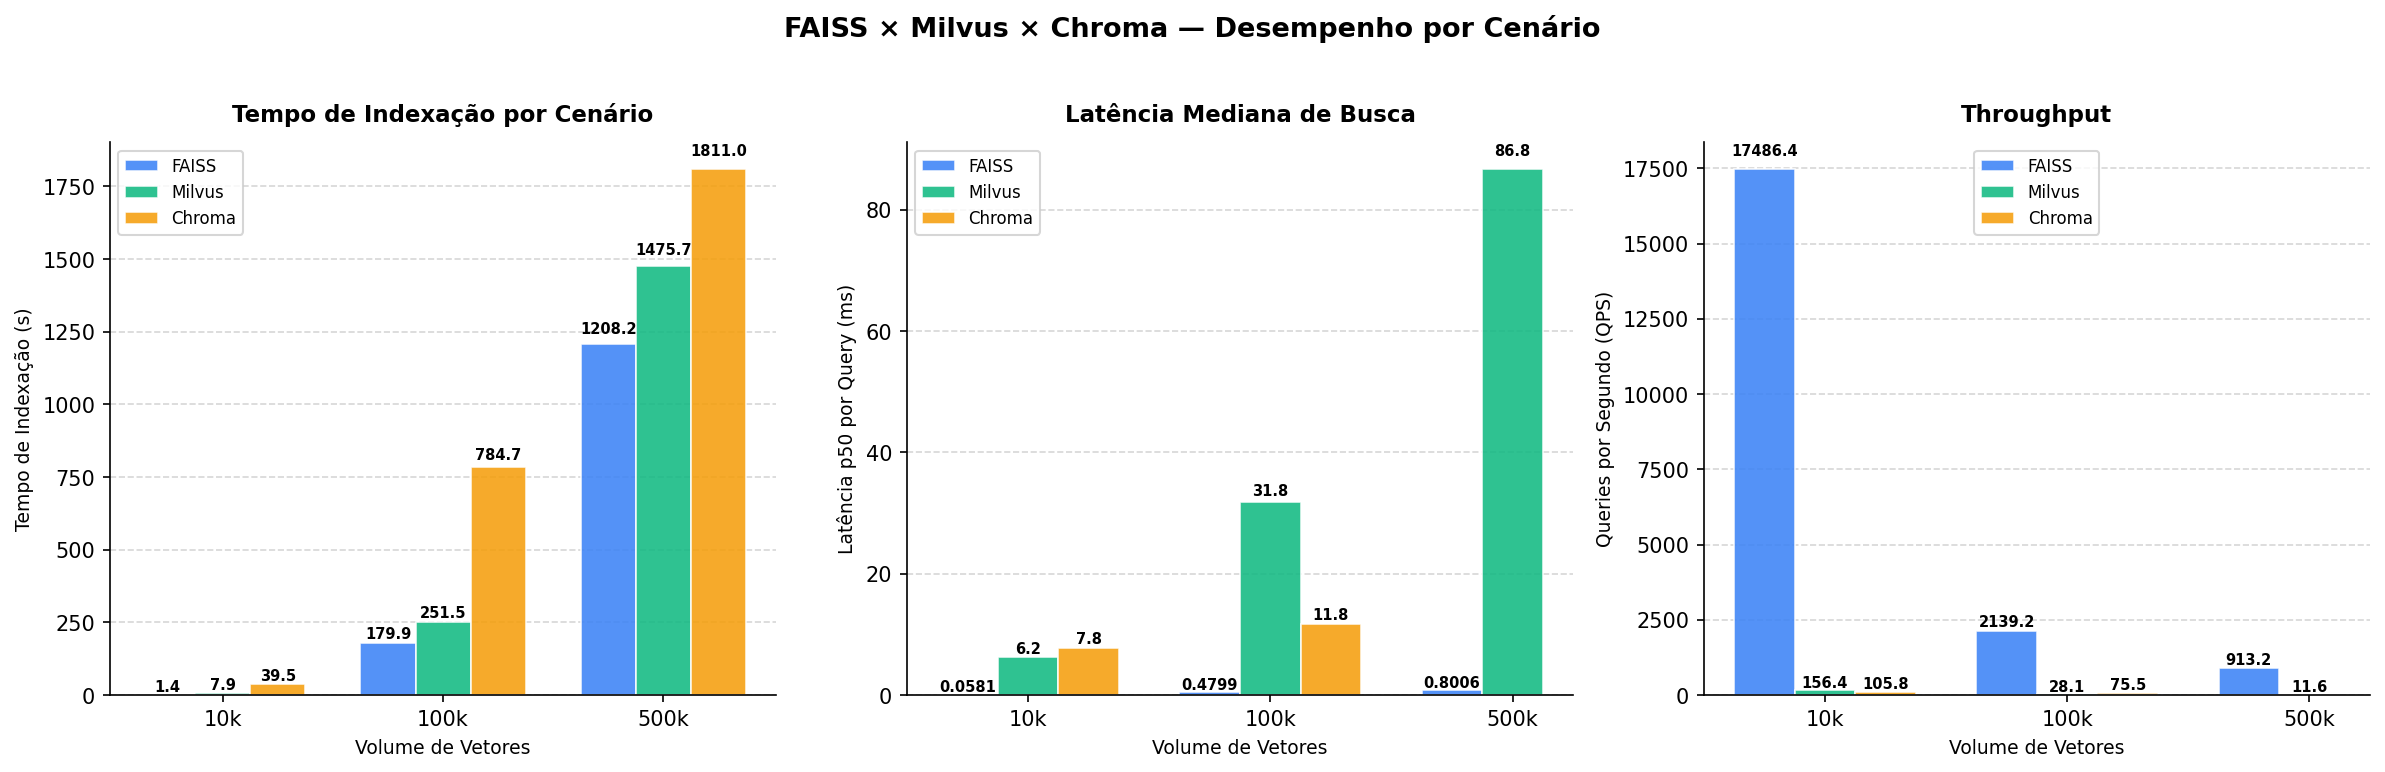

✅ Fig. 1 salva.


In [13]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
scenarios_labels = {"S1_10k": "10k", "S2_100k": "100k", "S3_500k": "500k"}
scen_keys = list(scenarios_labels.keys())
x = np.arange(len(scen_keys))
width = 0.25

metrics_to_plot = [
    ("Indexação (s)",    "Tempo de Indexação (s)",    "Tempo de Indexação por Cenário"),
    ("p50 (ms)",         "Latência p50 por Query (ms)", "Latência Mediana de Busca"),
    ("QPS",              "Queries por Segundo (QPS)",  "Throughput"),
]

for ax, (metric, ylabel, title) in zip(axes, metrics_to_plot):
    for i, db in enumerate(["FAISS", "Milvus", "Chroma"]):
        vals = []
        for s in scen_keys:
            row = df[(df["Banco"] == db) & (df["Cenário"] == s)]
            vals.append(row[metric].values[0] if not row.empty else np.nan)
        bars = ax.bar(x + i * width, vals, width, label=db,
                      color=COLORS[db], alpha=0.87, edgecolor="white", linewidth=0.8)
        for bar, v in zip(bars, vals):
            if not (np.isnan(v) if isinstance(v, float) else False):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                        f"{v:.1f}" if v >= 1 else f"{v:.4f}",
                        ha="center", va="bottom", fontsize=7, fontweight="bold")
    ax.set_title(title, fontsize=11, fontweight="bold", pad=10)
    ax.set_ylabel(ylabel, fontsize=9)
    ax.set_xticks(x + width)
    ax.set_xticklabels(["10k", "100k", "500k"], fontsize=10)
    ax.set_xlabel("Volume de Vetores", fontsize=9)
    ax.legend(fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig.suptitle("FAISS × Milvus × Chroma — Desempenho por Cenário",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(WORK_DIR / "fig1_desempenho.png", bbox_inches="tight", dpi=200)
plt.show()
print("✅ Fig. 1 salva.")


### Fig. 2 — Recall@k por Cenário

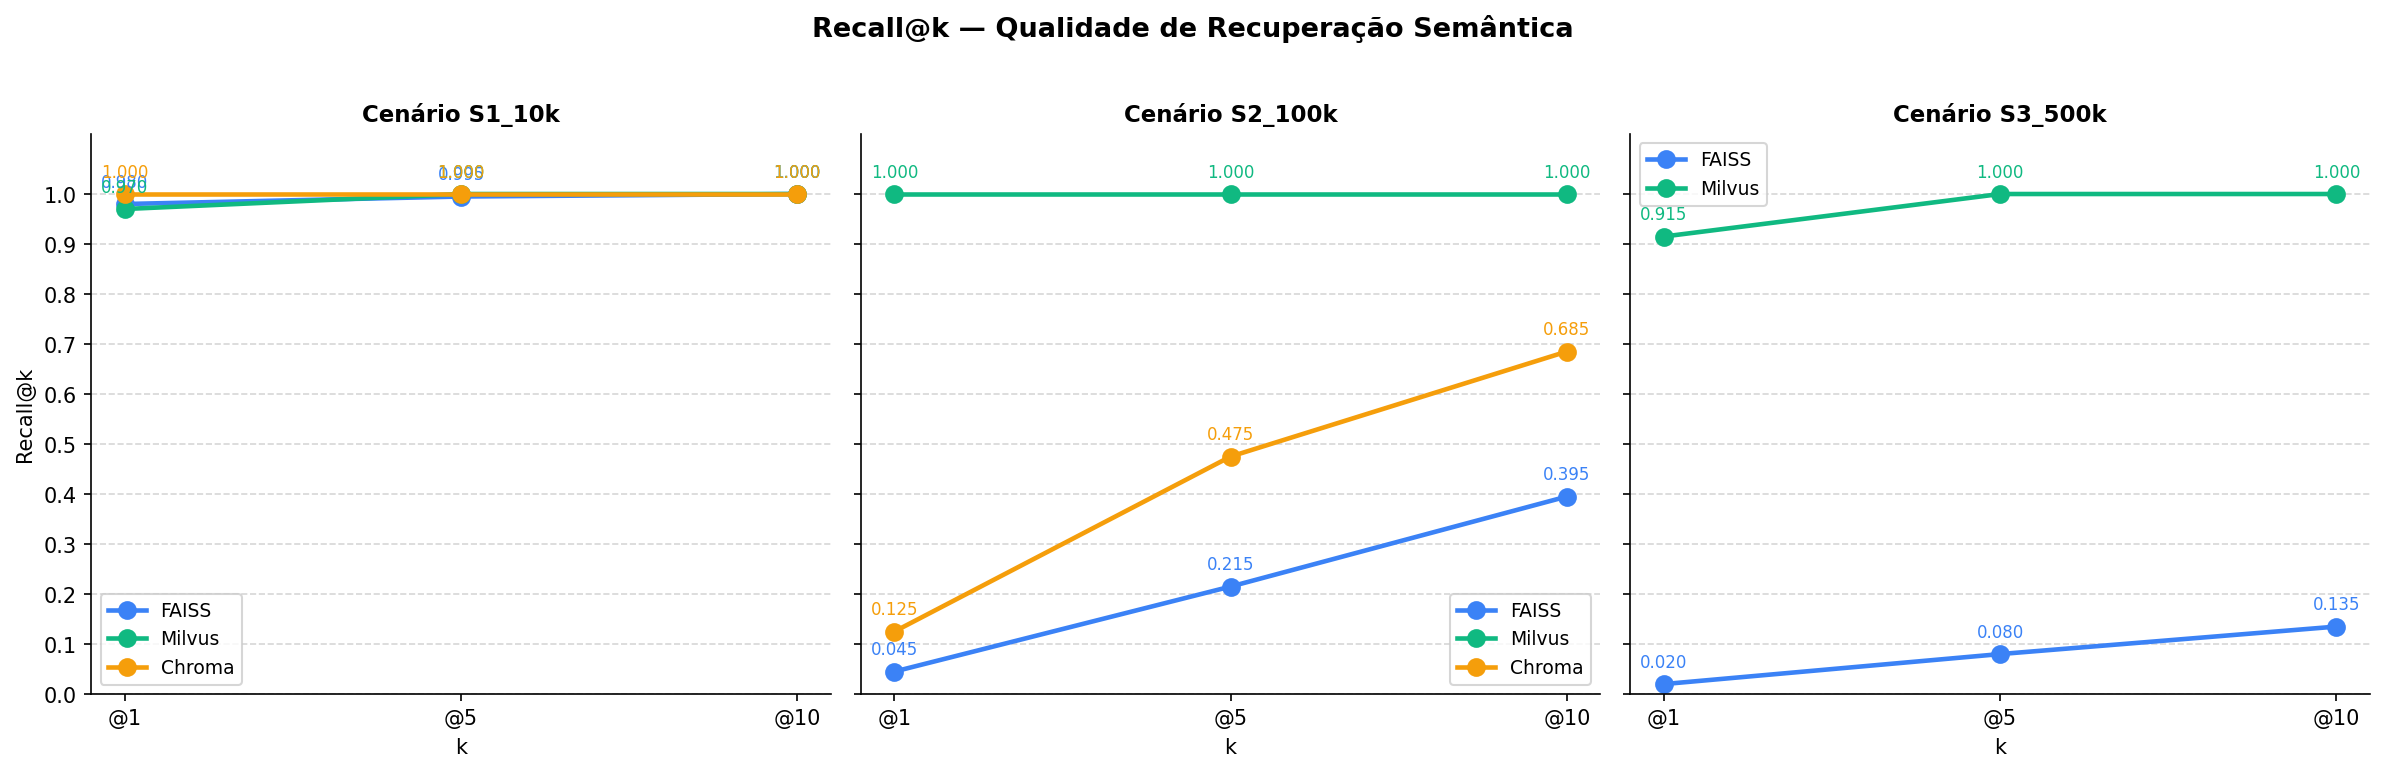

✅ Fig. 2 salva.


In [14]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=True)

for ax, scenario in zip(axes, scen_keys):
    subset = df[df["Cenário"] == scenario]
    for db in ["FAISS", "Milvus", "Chroma"]:
        row = subset[subset["Banco"] == db]
        if row.empty:
            continue
        vals = [row[c].values[0] for c in ["Recall@1", "Recall@5", "Recall@10"]]
        if any(np.isnan(v) if isinstance(v, float) else False for v in vals):
            continue
        k_labels = ["@1", "@5", "@10"]
        ax.plot(k_labels, vals, "o-", lw=2.2, ms=8, color=COLORS[db], label=db)
        for kl, v in zip(k_labels, vals):
            ax.annotate(f"{v:.3f}", (kl, v), textcoords="offset points",
                        xytext=(0, 8), ha="center", fontsize=8, color=COLORS[db])
    ax.set_title(f"Cenário {scenario}", fontsize=11, fontweight="bold")
    ax.set_xlabel("k", fontsize=10)
    ax.set_ylim(0, 1.12)
    ax.set_yticks(np.arange(0, 1.1, 0.1))
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)
    ax.legend(fontsize=9)

axes[0].set_ylabel("Recall@k", fontsize=10)
fig.suptitle("Recall@k — Qualidade de Recuperação Semântica",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(WORK_DIR / "fig2_recall_k.png", bbox_inches="tight", dpi=200)
plt.show()
print("✅ Fig. 2 salva.")


### Fig. 3 — Heatmap de Recursos (RAM e Disco)

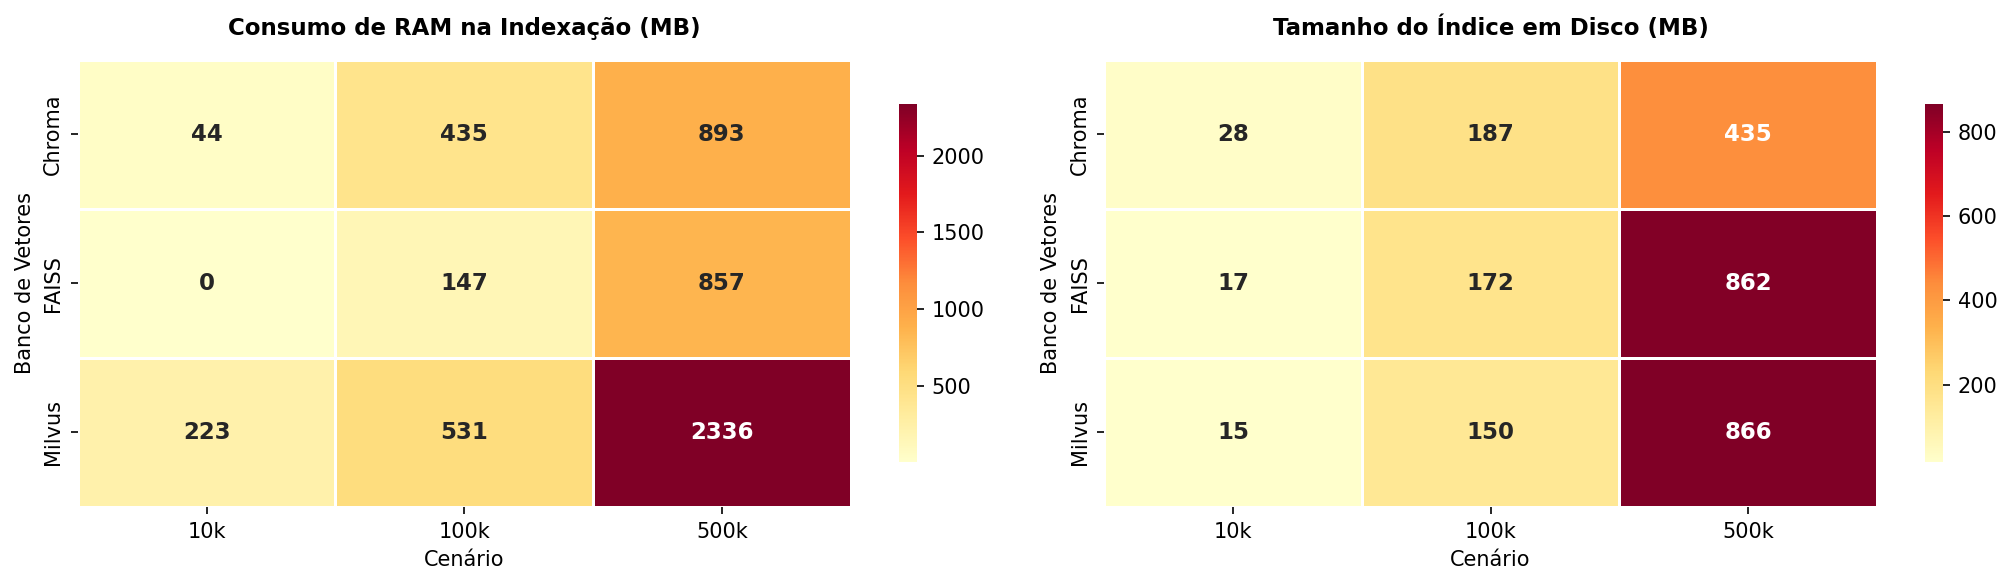

✅ Fig. 3 salva.


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, (metric, title) in zip(axes, [
    ("RAM (MB)",   "Consumo de RAM na Indexação (MB)"),
    ("Disco (MB)", "Tamanho do Índice em Disco (MB)"),
]):
    pivot = df.pivot_table(index="Banco", columns="Cenário", values=metric, aggfunc="first")
    existing = [s for s in scen_keys if s in pivot.columns]
    pivot = pivot[existing]
    sns.heatmap(pivot, ax=ax, annot=True, fmt=".0f", cmap="YlOrRd",
                linewidths=0.5, cbar_kws={"shrink": 0.8},
                annot_kws={"size": 11, "weight": "bold"})
    ax.set_title(title, fontsize=11, fontweight="bold", pad=12)
    ax.set_xlabel("Cenário", fontsize=10)
    ax.set_ylabel("Banco de Vetores", fontsize=10)
    ax.set_xticklabels(["10k", "100k", "500k"], fontsize=10)

plt.tight_layout()
plt.savefig(WORK_DIR / "fig3_recursos.png", bbox_inches="tight", dpi=200)
plt.show()
print("✅ Fig. 3 salva.")


### Fig. 4 — Distribuição de Latência (p50 e p99)

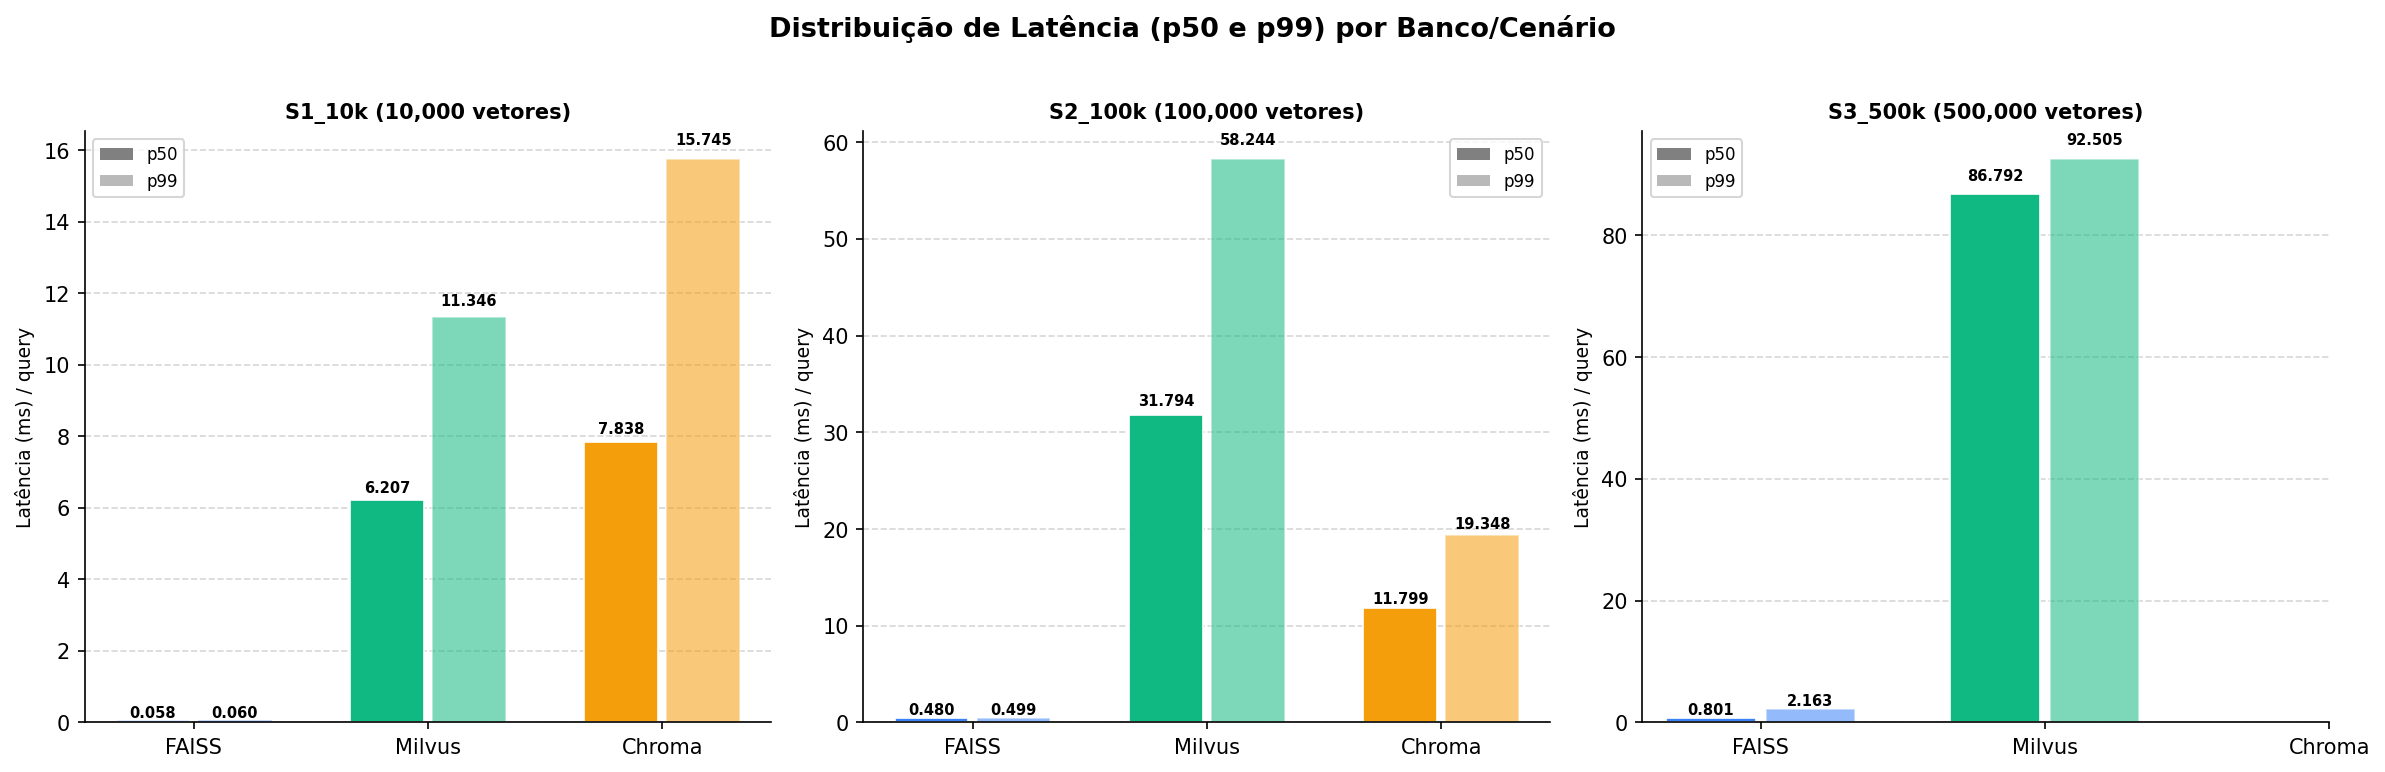

✅ Fig. 4 salva.


In [16]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
db_names = ["FAISS", "Milvus", "Chroma"]
xpos = np.arange(len(db_names))

for ax, scenario in zip(axes, scen_keys):
    subset = df[df["Cenário"] == scenario]
    n_vecs = SCENARIO_SIZES.get(scenario, 0)
    width  = 0.35

    for j, (col, lbl, alpha) in enumerate([
        ("p50 (ms)", "p50 (mediana)", 1.0),
        ("p99 (ms)", "p99 (cauda)",   0.55),
    ]):
        vals   = [subset[subset["Banco"] == db][col].values[0]
                  if not subset[subset["Banco"] == db].empty else np.nan
                  for db in db_names]
        colors = [COLORS[db] for db in db_names]
        offset = (j - 0.5) * width
        bars   = ax.bar(xpos + offset, vals, width*0.9, label=lbl,
                        color=colors, alpha=alpha, edgecolor="white", linewidth=0.8)
        for bar, v in zip(bars, vals):
            if not (np.isnan(v) if isinstance(v, float) else False):
                ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()*1.02,
                        f"{v:.3f}", ha="center", va="bottom", fontsize=7, fontweight="bold")

    ax.set_title(f"{scenario} ({n_vecs:,} vetores)", fontsize=10, fontweight="bold")
    ax.set_ylabel("Latência (ms) / query", fontsize=9)
    ax.set_xticks(xpos)
    ax.set_xticklabels(db_names, fontsize=10)
    p50_patch = mpatches.Patch(facecolor="gray", alpha=1.0, label="p50")
    p99_patch = mpatches.Patch(facecolor="gray", alpha=0.55, label="p99")
    ax.legend(handles=[p50_patch, p99_patch], fontsize=8)
    ax.yaxis.grid(True, linestyle="--", alpha=0.5)
    ax.set_axisbelow(True)

fig.suptitle("Distribuição de Latência (p50 e p99) por Banco/Cenário",
             fontsize=13, fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(WORK_DIR / "fig4_latencia.png", bbox_inches="tight", dpi=200)
plt.show()
print("✅ Fig. 4 salva.")


### Fig. 5 — Gráfico Radar Multidimensional (S1 + S2)

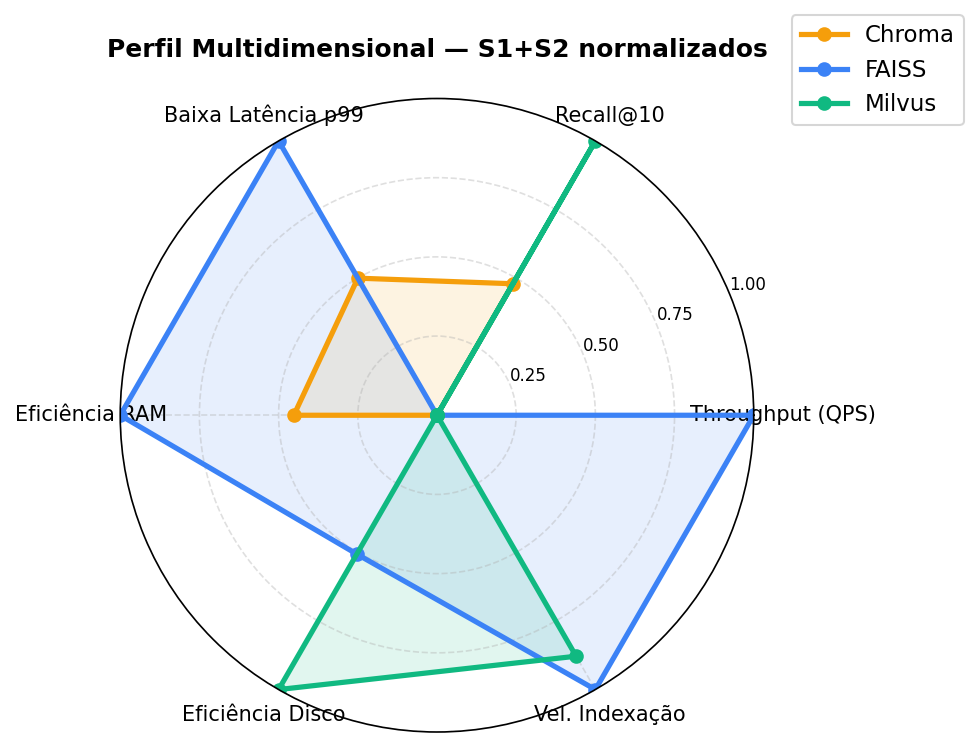

✅ Fig. 5 salva.


In [17]:
def normalize_col(series, higher_is_better):
    mn, mx = series.min(), series.max()
    if mx == mn:
        return pd.Series(0.5, index=series.index)
    norm = (series - mn) / (mx - mn)
    return norm if higher_is_better else (1 - norm)

RADAR_DIMS = [
    ("QPS",       True,  "Throughput (QPS)"),
    ("Recall@10", True,  "Recall@10"),
    ("p99 (ms)",  False, "Baixa Latência p99"),
    ("RAM (MB)",  False, "Eficiência RAM"),
    ("Disco (MB)",False, "Eficiência Disco"),
    ("Indexação (s)", False, "Vel. Indexação"),
]

# Agrega S1+S2 (exclui S3 para normalização justa; dados S3 Chroma podem ser NaN)
df_agg = (df[df["Cenário"].isin(["S1_10k", "S2_100k"])]
          .groupby("Banco")[["QPS","Recall@10","p99 (ms)","RAM (MB)","Disco (MB)","Indexação (s)"]]
          .mean()
          .reset_index())

for col, hib, _ in RADAR_DIMS:
    df_agg[f"{col}_norm"] = normalize_col(df_agg[col], hib)

norm_cols = [f"{col}_norm" for col, _, __ in RADAR_DIMS]
labels    = [lbl for _, __, lbl in RADAR_DIMS]
N         = len(RADAR_DIMS)
angles    = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles   += angles[:1]

fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
for _, row in df_agg.iterrows():
    db   = row["Banco"]
    vals = [row[c] for c in norm_cols] + [row[norm_cols[0]]]
    ax.plot(angles, vals, "o-", lw=2.5, color=COLORS[db], label=db)
    ax.fill(angles, vals, alpha=0.12, color=COLORS[db])

ax.set_thetagrids(np.degrees(angles[:-1]), labels, fontsize=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.25, 0.5, 0.75, 1.0])
ax.set_yticklabels(["0.25", "0.50", "0.75", "1.00"], fontsize=8)
ax.yaxis.grid(True, linestyle="--", alpha=0.4)
ax.xaxis.grid(True, linestyle="--", alpha=0.4)
ax.set_title("Perfil Multidimensional — S1+S2 normalizados",
             pad=20, fontsize=12, fontweight="bold")
ax.legend(loc="upper right", bbox_to_anchor=(1.35, 1.15), fontsize=11)

plt.tight_layout()
plt.savefig(WORK_DIR / "fig5_radar.png", bbox_inches="tight", dpi=200)
plt.show()
print("✅ Fig. 5 salva.")


## Seção 9 — Verificação, Ambiente e Exportação Final

### 9.1 Verificação Automática de Resultados

In [18]:
print("=" * 62)
print("  VERIFICAÇÃO DE ARTEFATOS — Fase 1.2")
print("=" * 62)

expected_csvs = [
    "resultados_completos.csv",
    "resultados_faiss_detalhado.csv",
    "resultados_milvus_detalhado.csv",
    "resultados_chroma_detalhado.csv",
    "resultados_ic95.csv",
    "resultados_wilcoxon.csv",
]
expected_figs = [f"fig{i}_{n}.png" for i, n in enumerate(
    ["desempenho","recall_k","recursos","latencia","radar"], start=1)]

all_ok = True

print("\n📄 CSVs:")
for fname in expected_csvs:
    path = WORK_DIR / fname
    if path.exists() and path.stat().st_size > 0:
        size_kb = path.stat().st_size / 1024
        print(f"  ✅ {fname:<45} {size_kb:>6.1f} KB")
    else:
        print(f"  ❌ {fname:<45} ausente ou vazio")
        all_ok = False

print("\n🖼️  Figuras:")
for fname in expected_figs:
    path = WORK_DIR / fname
    if path.exists() and path.stat().st_size > 50_000:   # > 50 KB
        size_kb = path.stat().st_size / 1024
        print(f"  ✅ {fname:<45} {size_kb:>6.1f} KB")
    else:
        print(f"  ❌ {fname:<45} ausente, vazio ou < 50 KB")
        all_ok = False

print("\n📊 Cobertura do CSV consolidado (3 bancos × 3 cenários = 9 linhas):")
n_rows    = len(df)
n_ok      = len(df[df["Status"] == "ok"])
n_timeout = len(df[df["Status"] == "timeout_insercao"])
print(f"  Linhas totais:  {n_rows} / 9 esperadas")
print(f"  Status 'ok':    {n_ok}")
print(f"  Timeouts:       {n_timeout}  (achado experimental — ver D6)")

if n_rows < 9:
    print("  ❌ Cobertura incompleta.")
    all_ok = False
else:
    print("  ✅ Cobertura completa.")

print(f"\n{'=' * 62}")
if all_ok:
    print("  ✅ TUDO OK — notebook pronto para Fase 1.2 de execução.")
else:
    print("  ❌ Há itens pendentes — revisar células acima antes de continuar.")
print(f"{'=' * 62}")


  VERIFICAÇÃO DE ARTEFATOS — Fase 1.2

📄 CSVs:
  ✅ resultados_completos.csv                         1.1 KB
  ✅ resultados_faiss_detalhado.csv                   2.3 KB
  ✅ resultados_milvus_detalhado.csv                  2.0 KB
  ✅ resultados_chroma_detalhado.csv                  0.9 KB
  ✅ resultados_ic95.csv                              0.4 KB
  ✅ resultados_wilcoxon.csv                          0.4 KB

🖼️  Figuras:
  ✅ fig1_desempenho.png                            169.3 KB
  ✅ fig2_recall_k.png                              146.1 KB
  ✅ fig3_recursos.png                               93.1 KB
  ✅ fig4_latencia.png                              133.9 KB
  ✅ fig5_radar.png                                 179.5 KB

📊 Cobertura do CSV consolidado (3 bancos × 3 cenários = 9 linhas):
  Linhas totais:  9 / 9 esperadas
  Status 'ok':    8
  Timeouts:       1  (achado experimental — ver D6)
  ✅ Cobertura completa.

  ✅ TUDO OK — notebook pronto para Fase 1.2 de execução.


### 9.2 Registro do Ambiente de Execução

In [19]:
import platform, sys

def get_lib_version(lib_name):
    try:
        import importlib.metadata
        return importlib.metadata.version(lib_name)
    except Exception:
        return "?"

ambiente = {
    "data_execucao": datetime.datetime.now().isoformat(),
    "sistema": {
        "os":           platform.system() + " " + platform.release(),
        "arquitetura":  platform.machine(),
        "python":       sys.version.split()[0],
        "cpu_fisicos":  psutil.cpu_count(logical=False),
        "cpu_logicos":  psutil.cpu_count(),
        "ram_total_gb": round(psutil.virtual_memory().total / (1024 ** 3), 2),
    },
    "bibliotecas": {
        "faiss-cpu":             get_lib_version("faiss-cpu"),
        "chromadb":              get_lib_version("chromadb"),
        "pymilvus":              get_lib_version("pymilvus"),
        "sentence-transformers": get_lib_version("sentence-transformers"),
        "datasets":              get_lib_version("datasets"),
        "numpy":                 np.__version__,
        "pandas":                pd.__version__,
        "scipy":                 get_lib_version("scipy"),
        "psutil":                get_lib_version("psutil"),
        "matplotlib":            get_lib_version("matplotlib"),
        "seaborn":               get_lib_version("seaborn"),
    },
    "experimento": {
        "seed":          SEED,
        "embedding_dim": EMBEDDING_DIM,
        "modelo_s1":     "sentence-transformers/all-MiniLM-L6-v2",
        "metrica":       "Inner Product (cosine em vetores normalizados)",
        "n_queries":     N_QUERIES,
        "n_runs":        N_RUNS,
        "cenarios":      {k: v for k, v in SCENARIO_SIZES.items()},
        "colab_mode":    COLAB_MODE,
    },
}

amb_path = WORK_DIR / "ambiente_execucao.json"
with open(amb_path, "w", encoding="utf-8") as f:
    json.dump(ambiente, f, indent=2, ensure_ascii=False)

try:
    shutil.copy(amb_path, Path(DRIVE_OUTPUT) / "ambiente_execucao.json")
except Exception:
    pass

print("=" * 55)
print("  AMBIENTE DE EXECUÇÃO — Seção 3.8 da Monografia")
print("=" * 55)
print(json.dumps(ambiente, indent=2, ensure_ascii=False))
print("\n✅ ambiente_execucao.json salvo em WORK_DIR e no Drive.")


  AMBIENTE DE EXECUÇÃO — Seção 3.8 da Monografia
{
  "data_execucao": "2026-08-21T01:25:31.347455",
  "sistema": {
    "os": "Linux 6.6.122+",
    "arquitetura": "x86_64",
    "python": "3.12.13",
    "cpu_fisicos": 1,
    "cpu_logicos": 2,
    "ram_total_gb": 12.67
  },
  "bibliotecas": {
    "faiss-cpu": "1.9.0",
    "chromadb": "0.6.3",
    "pymilvus": "2.5.8",
    "sentence-transformers": "3.4.1",
    "datasets": "3.2.0",
    "numpy": "2.0.2",
    "pandas": "2.2.3",
    "scipy": "1.15.2",
    "psutil": "6.1.1",
    "matplotlib": "3.10.0",
    "seaborn": "0.13.2"
  },
  "experimento": {
    "seed": 42,
    "embedding_dim": 384,
    "modelo_s1": "sentence-transformers/all-MiniLM-L6-v2",
    "metrica": "Inner Product (cosine em vetores normalizados)",
    "n_queries": 200,
    "n_runs": 10,
    "cenarios": {
      "S1_10k": 10000,
      "S2_100k": 100000,
      "S3_500k": 500000
    },
    "colab_mode": true
  }
}

✅ ambiente_execucao.json salvo em WORK_DIR e no Drive.


### 9.3 Cópia Final para o Google Drive

In [20]:
print("📦 Copiando todos os artefatos para o Google Drive...")
print(f"   Destino: {DRIVE_OUTPUT}\n")

os.makedirs(DRIVE_OUTPUT, exist_ok=True)
copied, skipped = [], []

for f in sorted(WORK_DIR.rglob("*")):
    if not f.is_file():
        continue
    # Não copiar arquivos de índice grandes (economiza espaço no Drive)
    if f.suffix in {".index", ".db"} and f.stat().st_size > 100 * 1024 * 1024:
        skipped.append(f.name)
        continue
    dest = Path(DRIVE_OUTPUT) / f.relative_to(WORK_DIR)
    dest.parent.mkdir(parents=True, exist_ok=True)
    try:
        shutil.copy2(f, dest)
        size_kb = f.stat().st_size / 1024
        copied.append((f.name, size_kb))
    except Exception as e:
        skipped.append(f"{f.name} (erro: {e})")

print(f"{'Arquivo':<50} {'Tamanho':>10}")
print("-" * 62)
for name, size_kb in copied:
    print(f"  {name:<48} {size_kb:>8.1f} KB")

if skipped:
    print(f"\n⚠️  Ignorados (índices > 100 MB ou erro):")
    for s in skipped:
        print(f"    {s}")

print(f"\n✅ {len(copied)} arquivo(s) copiado(s) para o Drive.")
print(f"   Pasta: {DRIVE_OUTPUT}")
print("\n🎉 Benchmark concluído! Notebook v2 — Fase 1.1 e 1.2 automatizadas.")


📦 Copiando todos os artefatos para o Google Drive...
   Destino: /content/drive/MyDrive/TCC_BenchmarkRAG

Arquivo                                               Tamanho
--------------------------------------------------------------
  ambiente_execucao.json                                0.9 KB
  data_level0.bin                                   16367.2 KB
  header.bin                                            0.1 KB
  index_metadata.pickle                               250.9 KB
  length.bin                                           39.1 KB
  link_lists.bin                                       84.0 KB
  chroma.sqlite3                                    11480.0 KB
  data_level0.bin                                  163671.9 KB
  header.bin                                            0.1 KB
  index_metadata.pickle                              2826.8 KB
  length.bin                                          390.6 KB
  link_lists.bin                                      824.3 KB
  chroma.sqli